# Demand Forecasting Project

## EDA and Data Cleaning


**Dataset:** Online Retail II — UCI Machine Learning Repository

The goal here is to go from the raw Excel file all the way to a clean, aggregated dataset that I can actually use for modelling.

The dataset comes in two sheets — one for 2009–2010 and one for 2010–2011.

In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/demand_forecasting'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Colab directory ready: {SAVE_DIR}')

Mounted at /content/drive
Colab directory ready: /content/drive/MyDrive/demand_forecasting


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams.update({
    'figure.dpi'     : 120,
    'axes.titlesize' : 13,
    'axes.labelsize' : 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.titlepad'  : 10,
})

C_BLUE  = '#2E86AB'
C_RED   = '#E84855'
C_GREEN = '#3BB273'

print('Libraries loaded.')

Libraries loaded.


##  Loading the Data

The dataset is an Excel file with two sheets — one per fiscal year. Reading them separately first to check their sizes, then concatenating.

**Column reference** (from the UCI dataset page):

| Column | Type | Description |
|---|---|---|
| **Invoice** | str | Transaction ID — starts with `C` if it is a cancellation |
| **StockCode** | str | Product code |
| **Description** | str | Product name |
| **Quantity** | int | Number of units per transaction line |
| **InvoiceDate** | datetime | Date and time of the transaction |
| **Price** | float | Unit price in GBP |
| **Customer ID** | float | Anonymised customer number (null for guest checkouts) |
| **Country** | str | Country of the customer |

In [3]:
df1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
print(f'Sheet 1: {df1.shape}')
print(f'Sheet 2: {df2.shape}')

df = pd.concat([df1, df2], ignore_index=True)
del df1, df2
print(f'Combined shape: {df.shape}')
print(f'Combined size: {df.size}')
print(f'Random samples: \n {df.sample(10, random_state=42)}')
print(f'Columns and data types: \n {df.dtypes}')
print(f'Dataset Description: \n{df.describe()}')
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

print('Columns with missing values:')
pd.DataFrame({'count': missing, 'pct_%': missing_pct})[missing > 0]

Sheet 1: (525461, 8)
Sheet 2: (541910, 8)
Combined shape: (1067371, 8)
Combined size: 8538968
Random samples: 
        Invoice StockCode                       Description  Quantity  \
455941  532657     21314     SMALL GLASS HEART TRINKET POT        12   
826291  563214     22383            LUNCH BAG SUKI DESIGN          2   
191636  507597     22561       WOODEN SCHOOL COLOURING SET        12   
25864   491634     21588    RETRO SPOT GIANT  TUBE MATCHES         1   
73233   496007    85232B  SET/3 RUSSIAN DOLL STACKING TINS         3   
557542  539041     21832              CHOCOLATE CALCULATOR         4   
985772  575905     22089     PAPER BUNTING VINTAGE PAISLEY         6   
568585  540026     21519   GIN & TONIC DIET GREETING CARD          2   
530265  536804     22988                 SOLDIERS EGG CUP         72   
649024  546899     20719            WOODLAND CHARLOTTE BAG        50   

               InvoiceDate  Price  Customer ID         Country  
455941 2010-11-14 11:10:00   2

,count,pct_%
Description,4382,0.41
Customer ID,243007,22.77


**Observation:** Only two columns have missing values — **Description** (very small, $=$0.41%) and **Customer ID** ($=$22.77%).

The Customer ID nulls are from guest checkouts — this is expected and documented in the dataset description on UCI. The high null rate is not a data quality problem . I am going to drop them in the cleaning step because I plan to use Customer ID as a count-of-distinct-customers feature when aggregating to weekly level, so rows without it are not useful.

## Data Quality Audit
Four things to investigate:
- Cancellation invoices
- Non-product stock codes (system/admin entries)
- Negative or zero quantities and prices
- Extreme outlier values

### 1 — Cancellation Invoices

Invoices starting with **C** are cancellations — they reverse a previous order and show up as negative quantities. If I leave them in, the model would see artificial negative demand, which is not real. They need to be removed.

In [4]:
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
print(f'Cancelled invoices:{len(cancelled):,}')
print(f'Percentage: {len(cancelled)/len(df)*100:.1f}%')
print(cancelled[['Invoice','Quantity','Price']].head())

Cancelled invoices:19,494
Percentage: 1.8%
     Invoice  Quantity  Price
178  C489449       -12   2.95
179  C489449        -6   1.65
180  C489449        -4   4.25
181  C489449        -6   2.10
182  C489449       -12   2.95


As expected — cancellations have negative quantities and all have invoice codes starting with C. About 1.8% of rows fall into this category.

### 2 — Non-Product Stock Codes

Looking at the top stock codes by frequency, some are clearly not real products — things like **POST** (postage), **BANK CHARGES**, **AMAZONFEE**, **M** (manual entry). These are system or accounting entries. I need to find them and remove them, otherwise the model would try to forecast demand for "bank charges" as if it were a product.

In [5]:
print('Sample StockCodes:')
print(df['StockCode'].value_counts().head(20))
print()
non_product = ['POST','DOT','BANK CHARGES','M','D','CRUK','S','AMAZONFEE','C2','PADS','B','ADJUST']
print('Non-product code counts:')
for code in non_product:
  n = (df['StockCode'].astype(str) == code).sum()
  if n > 0:
    print(f' {code}: {n}')

Sample StockCodes:
StockCode
85123A    5829
22423     4424
85099B    4216
21212     3318
20725     3259
84879     2960
47566     2768
21232     2747
22197     2549
22383     2540
20727     2529
21931     2434
22386     2347
22469     2325
22411     2297
84991     2271
22382     2251
22384     2230
21080     2224
22086     2217
Name: count, dtype: int64

Non-product code counts:
 POST: 2122
 DOT: 1446
 BANK CHARGES: 102
 M: 1421
 D: 177
 CRUK: 16
 S: 104
 AMAZONFEE: 43
 C2: 282
 PADS: 19
 B: 6
 ADJUST: 67


### 3 — Quantity and Price Anomalies

From the descriptive stats earlier, Quantity has a very large maximum value and Price can be zero or negative. I want to quantify exactly how many rows have these issues before removing them.

In [6]:
print('Quantity statistics:')
print(df['Quantity'].describe().round(2))
print()
print('Price statistics:')
print(df['Price'].describe().round(2))
print()
print(f'Products with Quantity > 0: {(df["Quantity"] > 0).sum():,}')
print(f'Products with Quantity <= 0: {(df["Quantity"] <= 0).sum():,}')
print(f'Products with Price <= 0: {(df["Price"] <= 0).sum():,}')

Quantity statistics:
count    1067371.00
mean           9.94
std          172.71
min       -80995.00
25%            1.00
50%            3.00
75%           10.00
max        80995.00
Name: Quantity, dtype: float64

Price statistics:
count    1067371.00
mean           4.65
std          123.55
min       -53594.36
25%            1.25
50%            2.10
75%            4.15
max        38970.00
Name: Price, dtype: float64

Products with Quantity > 0: 1,044,421
Products with Quantity <= 0: 22,950
Products with Price <= 0: 6,207


The extreme max values — Quantity in the tens of thousands in a single row — are almost certainly warehouse transfers or data entry errors, not real consumer demand. These will distort any model trained on them if left in. Negative prices are adjustments or errors.

Remove negatives and zeros entirely, then clip the top 1% as a conservative outlier filter.

##  Cleaning Pipeline

Applying all the fixes identified in the audit above. Printing the row count after every step so the impact of each decision is visible — this also serves as a good audit trail for the write-up.

| Step | What I remove | Why |
|------|------|-----|
| 1 | Invoices starting with **C** | Cancellations are order reversals, not real demand |
| 2 | Rows where **Quantity <= 0** or **Price <= 0** | Negatives and zeros are errors or adjustment entries |
| 3 | Rows with null **Customer ID** | Need it as a feature (unique customers per week) during aggregation |
| 4 | Known non-product **StockCodes** | System entries — postage, fees, manual adjustments |
| 5 | Rows above the 99th percentile for Quantity and Price | Extreme values are warehouse noise, not consumer demand |

In [7]:
raw_count = df.shape[0]
print(f'Starting row count : {raw_count:,}')

#Remove cancellations
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f'After removing cancellations:{df.shape[0]:,}')

# Keep only positive quantity and price
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print(f'After positive filter: {df.shape[0]:,}')

#Remove missing Customer IDs
df = df.dropna(subset=['Customer ID'])
print(f'After dropping null Customer IDs: {df.shape[0]:,}')

# Remove non-product stock codes
df = df[~df['StockCode'].astype(str).isin(non_product)]
print(f'After removing bad codes: {df.shape[0]:,}')

# Convert date column, compute Revenue, clip outliers
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue']     = df['Price'] * df['Quantity']

q99_qty   = df['Quantity'].quantile(0.99)
q99_price = df['Price'].quantile(0.99)
df = df[(df['Quantity'] <= q99_qty) & (df['Price'] <= q99_price)]
print(f'After 99th percentile clip      : {df.shape[0]:,}')

total_removed = raw_count - df.shape[0]
print()
print(f'Total rows removed : {total_removed:,}  ({total_removed / raw_count * 100:.1f}% of raw data)')
print(f'Unique products remaining : {df["StockCode"].nunique():,}')

Starting row count : 1,067,371
After removing cancellations:1,047,877
After positive filter: 1,041,670
After dropping null Customer IDs: 805,549
After removing bad codes: 802,647
After 99th percentile clip      : 787,685

Total rows removed : 279,686  (26.2% of raw data)
Unique products remaining : 4,538


Removed about 26% of the raw data across 5 steps. Every removal is justified above. The remaining row count and unique product count look reasonable for the modelling task.

##  Weekly Aggregation

The raw data is at the **transaction line level** — one row per product per invoice. For demand forecasting I need it at the **product × week level** — one row per product per week, with total quantity sold, average price, total revenue, etc.

I am using ISO week numbering (**isocalendar()**) because it is consistent — weeks always start on Monday, and the ISO year number aligns with the actual week rather than having a week-52 bleed into January.

The **15-week minimum filter** at the end removes products that do not have enough history for the model to learn from. With only a few weeks of data you cannot compute lag features or detect any seasonal pattern — better to exclude them than train on noise.

In [8]:
df['Year'] = df['InvoiceDate'].dt.isocalendar().year.astype(int)
df['Week'] = df['InvoiceDate'].dt.isocalendar().week.astype(int)

# Aggregate to one row per product per week
weekly = (
    df.groupby(['StockCode', 'Year', 'Week'])
    .agg(
        total_quantity   = ('Quantity',    'sum'),
        avg_price        = ('Price',       'mean'),
        total_revenue    = ('Revenue',     'sum'),
        num_transactions = ('Invoice',     'nunique'),
        num_customers    = ('Customer ID', 'nunique'),
        description      = ('Description', 'first'),
    )
    .reset_index()
)

# Convert Year + ISO Week back to an actual Monday date
weekly['date'] = pd.to_datetime(
    weekly['Year'].astype(str) + '-W' +
    weekly['Week'].astype(str).str.zfill(2) + '-1',
    format='%G-W%V-%u'
)

# Keep only products with at least 15 weeks of observations
weeks_per_product = weekly.groupby('StockCode').size()
valid_products    = weeks_per_product[weeks_per_product >= 15].index
weekly = weekly[weekly['StockCode'].isin(valid_products)]
weekly = weekly.sort_values(['StockCode', 'date']).reset_index(drop=True)

print(f'Weekly dataset shape : {weekly.shape}')
print(f'Unique products      : {weekly["StockCode"].nunique():,}')
print(f'Date range           : {weekly["date"].min().date()} to {weekly["date"].max().date()}')
print()
weekly.head()

Weekly dataset shape : (159645, 10)
Unique products      : 3,139
Date range           : 2009-11-30 to 2011-12-05



,StockCode,Year,Week,total_quantity,avg_price,total_revenue,num_transactions,num_customers,description,date
0,10002,2009,49,141,0.85,119.85,10,10,INFLATABLE POLITICAL GLOBE,2009-11-30
1,10002,2009,50,23,0.85,19.55,3,3,INFLATABLE POLITICAL GLOBE,2009-12-07
2,10002,2009,51,36,0.85,30.60,2,2,INFLATABLE POLITICAL GLOBE,2009-12-14
3,10002,2009,52,13,0.85,11.05,2,2,INFLATABLE POLITICAL GLOBE,2009-12-21
4,10002,2010,1,15,0.85,12.75,2,2,INFLATABLE POLITICAL GLOBE,2010-01-04


3,139 products with 159,645 weekly observations. This is the dataset I will use for all modelling. The date range covers just over two years, which is enough for seasonal patterns to show up clearly.

##  Exploratory Analysis


### 1 — Distributions of Demand, Price, and Revenue

First thing I want to know: what is the shape of the target variable (**total_quantity**) and the key covariates? Heavily skewed distributions can cause problems for some models and may need a log transform.

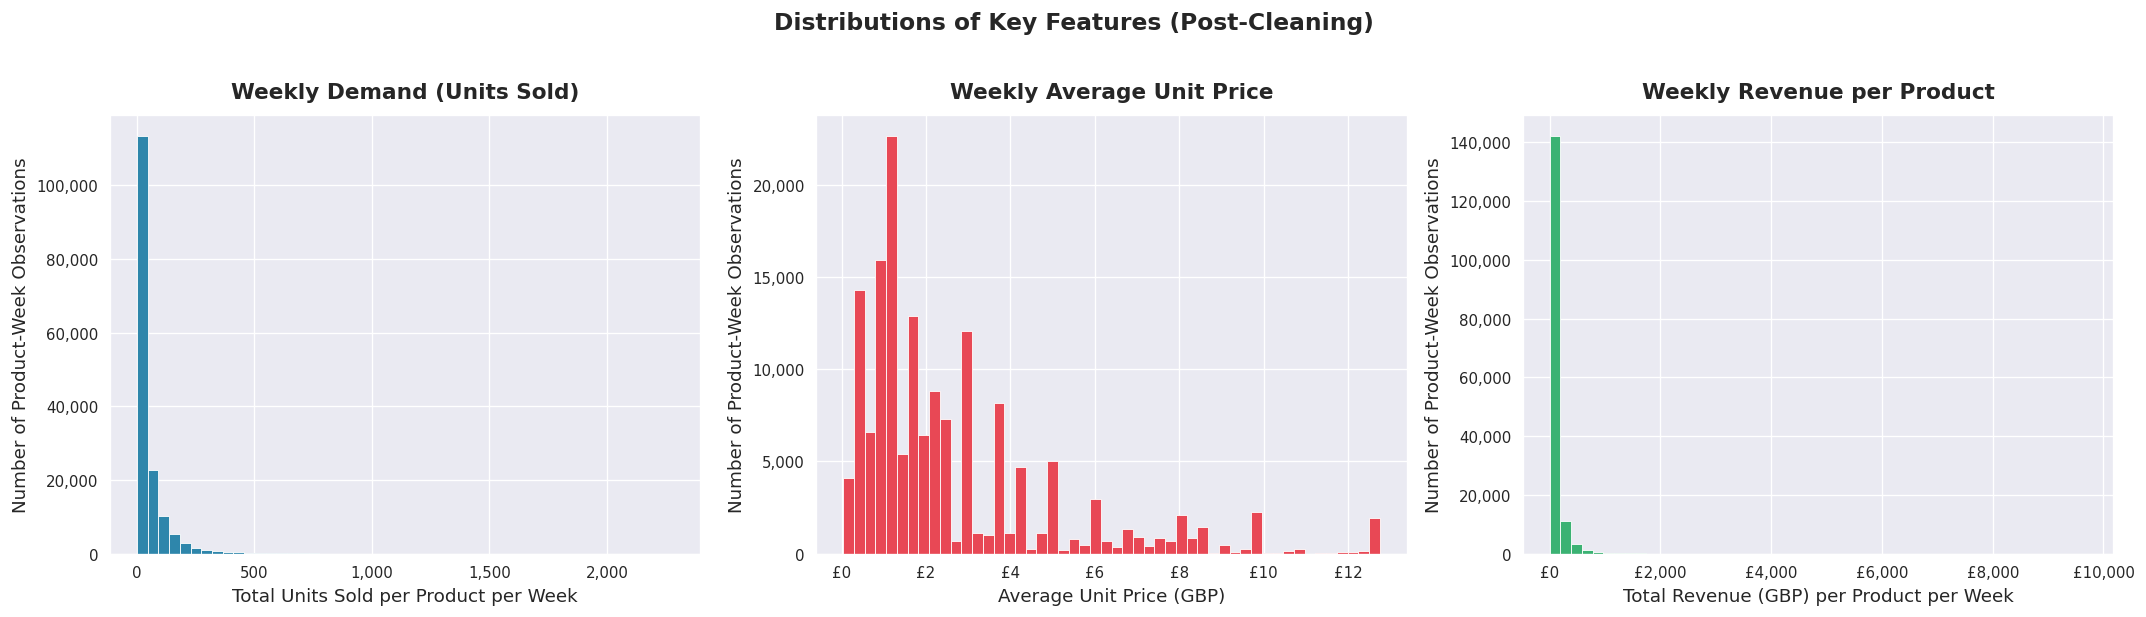

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distributions of Key Features (Post-Cleaning)', fontsize=14, fontweight='bold', y=1.02)

# Plot 1 — Weekly demand
axes[0].hist(weekly['total_quantity'], bins=50, color=C_BLUE, edgecolor='white', linewidth=0.5)
axes[0].set_title('Weekly Demand (Units Sold)', fontweight='bold')
axes[0].set_xlabel('Total Units Sold per Product per Week')
axes[0].set_ylabel('Number of Product-Week Observations')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Plot 2 — Average unit price
axes[1].hist(weekly['avg_price'], bins=50, color=C_RED, edgecolor='white', linewidth=0.5)
axes[1].set_title('Weekly Average Unit Price', fontweight='bold')
axes[1].set_xlabel('Average Unit Price (GBP)')
axes[1].set_ylabel('Number of Product-Week Observations')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Plot 3 — Weekly revenue
axes[2].hist(weekly['total_revenue'], bins=50, color=C_GREEN, edgecolor='white', linewidth=0.5)
axes[2].set_title('Weekly Revenue per Product', fontweight='bold')
axes[2].set_xlabel('Total Revenue (GBP) per Product per Week')
axes[2].set_ylabel('Number of Product-Week Observations')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{int(x):,}'))
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
#plt.savefig(f'{SAVE_DIR}/fig_01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
#print('Saved: fig_01_distributions.png')

All three are heavily right-skewed. Most products sell small quantities at low prices most weeks, with a long tail of high-volume and high-revenue products. This is typical for retail data.

**What this means for modelling:** I will likely need to log-transform **total_quantity** before training. Without it, regression models will over-weight the rare high-volume weeks when minimising MSE.

### 2 — Price vs. Demand Relationship

Intuitively, higher prices should mean lower demand. But is that actually true for this dataset? And is the relationship consistent across all products, or does it vary?

Two plots here: a scatter to see the aggregate pattern, and a per-product correlation histogram to check whether the relationship varies by product.

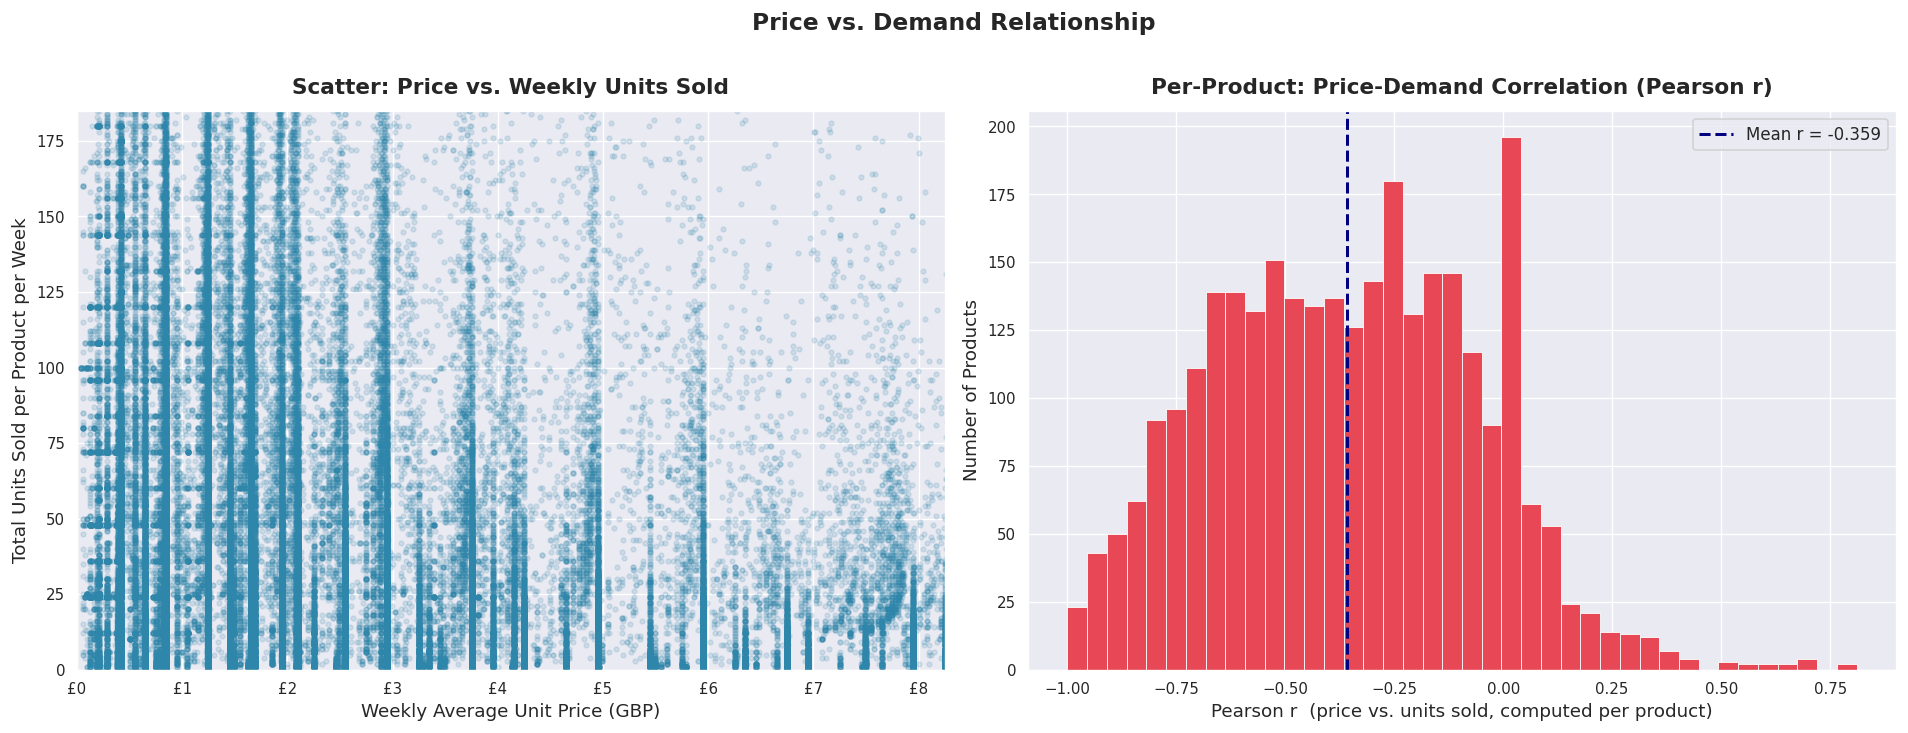

Mean per-product correlation : -0.359
Std of correlations          : 0.303


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Price vs. Demand Relationship', fontsize=14, fontweight='bold', y=1.01)

# Scatter: price vs units sold
axes[0].scatter(
    weekly['avg_price'], weekly['total_quantity'],
    alpha=0.15, s=8, color=C_BLUE, rasterized=True
)
axes[0].set_xlim(0, weekly['avg_price'].quantile(0.95))
axes[0].set_ylim(0, weekly['total_quantity'].quantile(0.95))
axes[0].set_title('Scatter: Price vs. Weekly Units Sold', fontweight='bold')
axes[0].set_xlabel('Weekly Average Unit Price (GBP)')
axes[0].set_ylabel('Total Units Sold per Product per Week')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}'))

# Per-product Pearson correlation between price and demand
product_corr = (
    weekly.groupby('StockCode')
    .apply(lambda x: x['avg_price'].corr(x['total_quantity']))
    .dropna()
)
axes[1].hist(product_corr, bins=40, color=C_RED, edgecolor='white', linewidth=0.5)
axes[1].axvline(
    product_corr.mean(), color='navy', linestyle='--', linewidth=1.8,
    label=f'Mean r = {product_corr.mean():.3f}'
)
axes[1].legend()
axes[1].set_title('Per-Product: Price-Demand Correlation (Pearson r)', fontweight='bold')
axes[1].set_xlabel('Pearson r  (price vs. units sold, computed per product)')
axes[1].set_ylabel('Number of Products')

plt.tight_layout()
#plt.savefig(f'{SAVE_DIR}/fig_02_price_demand.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean per-product correlation : {product_corr.mean():.3f}')
print(f'Std of correlations          : {product_corr.std():.3f}')
#print('Saved: fig_02_price_demand.png')

Two things stand out:

1. **The scatter does not show a clean global pattern** — no obvious downward slope, just a cloud. Different products clearly behave differently.

2. **The correlation histogram has a negative mean** (~−0.36), which aligns with economic theory. But the distribution is wide — some products even show a positive correlation. These could be items where higher price signals higher quality, or cases where both price and demand increase seasonally at the same time.

**What this means for modelling:** A single global model treating price the same for all products will struggle. Product-level features, or a model that can learn per-product interactions, will be important.

### 3 — Seasonal Demand Pattern

Does demand follow a seasonal pattern? And if it does, is it consistent enough across years to be reliable as a predictor?

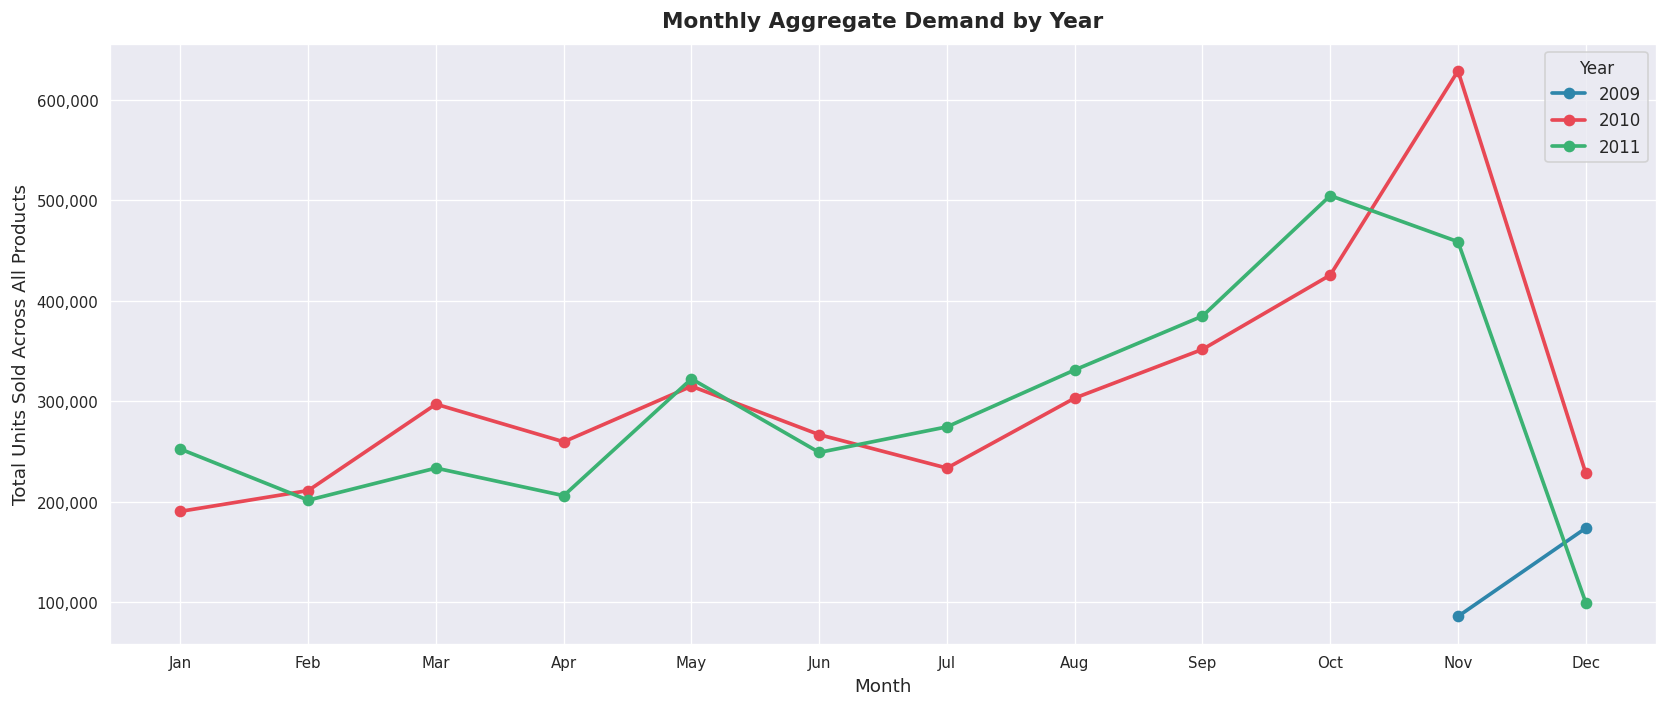

Saved: fig_03_seasonality.png


In [13]:
weekly['year_label'] = weekly['date'].dt.year
weekly['month']      = weekly['date'].dt.month

monthly = (weekly.groupby(['year_label', 'month'])['total_quantity'].sum().reset_index())

MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
YEAR_COLOURS = ['#2E86AB', '#E84855', '#3BB273', '#F4A261']

fig, ax = plt.subplots(figsize=(14, 6))

for i, year in enumerate(sorted(monthly['year_label'].unique())):
    d = monthly[monthly['year_label'] == year]
    ax.plot(d['month'], d['total_quantity'], 'o-', linewidth=2.2, markersize=6,
        color=YEAR_COLOURS[i % len(YEAR_COLOURS)], label=str(year))

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS)
ax.set_xlabel('Month')
ax.set_ylabel('Total Units Sold Across All Products')
ax.set_title('Monthly Aggregate Demand by Year', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Year')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_03_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_03_seasonality.png')

There is a clear and consistent Q4 spike (September–November) across all years — the holiday gifting season. It repeats every year in the same way. Demand then drops sharply in January. 2009 only shows two months — the dataset starts from late November 2009.

**What this means for modelling:** Month and week-of-year should be included as features. The pattern is structural and consistent, so the model should be able to learn it reliably. If I do not include calendar features, the model will be systematically wrong every Q4.

### 4 — Price Elasticity Segmentation

Based on the per-product correlations, I want to segment products into three rough buckets: elastic (strongly price-sensitive), inelastic (not sensitive to price), and moderate. The thresholds (r < −0.3 = elastic, r > −0.1 = inelastic) are somewhat arbitrary but give a reasonable split — I can revisit them later if needed.

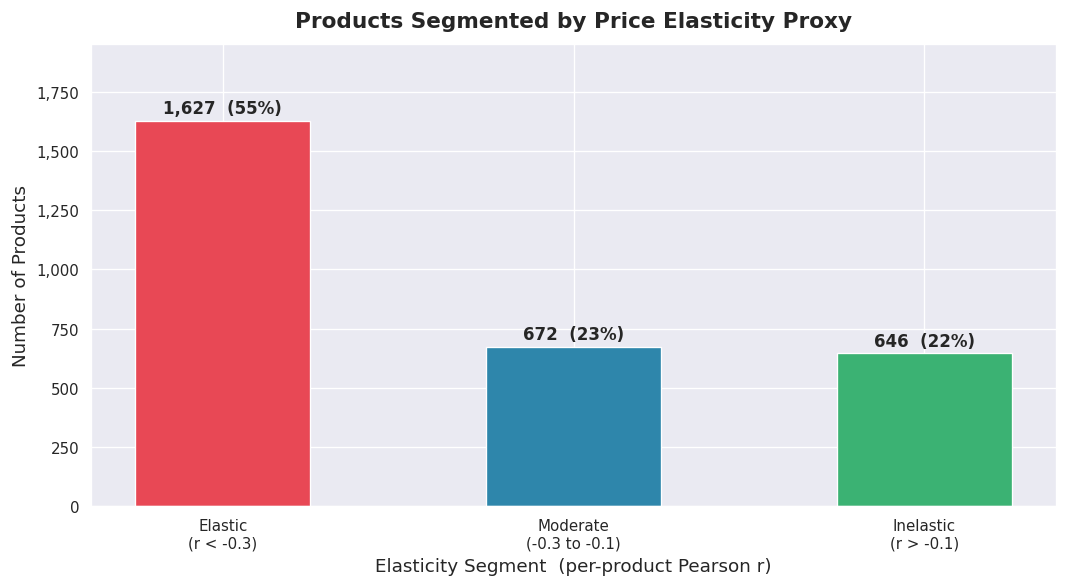

Elastic   (r < -0.3)   : 1,627  (55%)
Moderate  (-0.3 to -0.1): 672  (23%)
Inelastic (r > -0.1)   : 646  (22%)
Saved: fig_04_elasticity.png


In [14]:
elast = (weekly.groupby('StockCode').apply(lambda x: x['avg_price'].corr(x['total_quantity'])).dropna())

elastic   = (elast < -0.3).sum()
inelastic = (elast > -0.1).sum()
moderate  = len(elast) - elastic - inelastic

segment_labels = ['Elastic\n(r < -0.3)', 'Moderate\n(-0.3 to -0.1)', 'Inelastic\n(r > -0.1)']
segment_values = [elastic, moderate, inelastic]
segment_colors = [C_RED, C_BLUE, C_GREEN]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(segment_labels, segment_values, color=segment_colors,
              edgecolor='white', linewidth=0.8, width=0.5)

for bar, val in zip(bars, segment_values):
    pct = val / len(elast) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f'{val:,}  ({pct:.0f}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Products Segmented by Price Elasticity Proxy', fontweight='bold')
ax.set_xlabel('Elasticity Segment  (per-product Pearson r)')
ax.set_ylabel('Number of Products')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, max(segment_values) * 1.2)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_04_elasticity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Elastic   (r < -0.3)   : {elastic:,}  ({elastic/len(elast)*100:.0f}%)')
print(f'Moderate  (-0.3 to -0.1): {moderate:,}  ({moderate/len(elast)*100:.0f}%)')
print(f'Inelastic (r > -0.1)   : {inelastic:,}  ({inelastic/len(elast)*100:.0f}%)')
print('Saved: fig_04_elasticity.png')

Over half the products are price-elastic — demand reacts strongly to price changes. About 20% are inelastic — these are the ones where you could theoretically raise prices without losing much volume.

I will encode this as a categorical feature (**elasticity_segment**) in notebook 02. It might help the model distinguish between product types without needing to re-learn the pricing behaviour from scratch.

### 5 — Feature Correlation Heatmap

Quick check on how the numeric features relate to each other and to the target. Specifically: are any features redundant (very high inter-correlation)? Which ones are most correlated with demand?

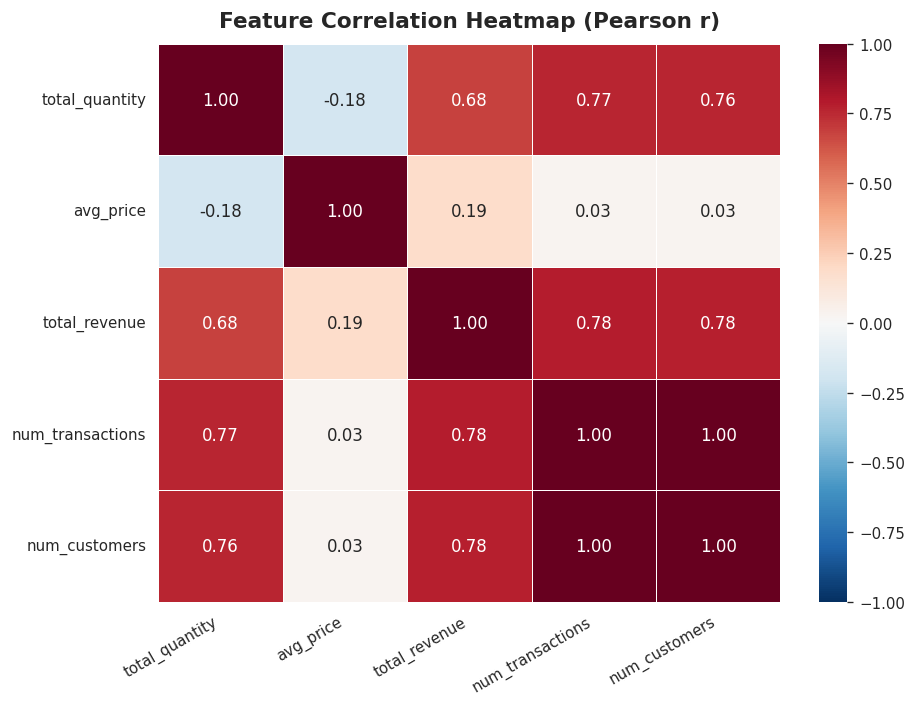

Saved: fig_05_correlation.png


In [15]:
corr_cols = ['total_quantity', 'avg_price', 'total_revenue', 'num_transactions', 'num_customers']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    weekly[corr_cols].corr(),
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax
)
ax.set_title('Feature Correlation Heatmap (Pearson r)', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_05_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_05_correlation.png')

A few things to note:

- **num_transactions** and **num_customers** are both positively correlated with **total_quantity** — more buyers and more orders predict more units sold. Makes sense. Both are worth including as features.
- **avg_price** has a weak aggregate correlation with demand, consistent with the finding — the signal is there at the product level but gets diluted in the aggregate.
- **total_revenue** is highly correlated with **total_quantity** — which is expected because revenue = price × quantity, making it partially a function of the target. I will **exclude total_revenue** as a direct feature to avoid data leakage.
- **num_transactions** and **num_customers** are correlated with each other, but they measure different things (order frequency vs. unique buyer count). I will keep both for now and see what feature importance says later.

In [16]:
WEEKLY_PATH = f'{SAVE_DIR}/weekly_clean.parquet'
weekly['StockCode'] = weekly['StockCode'].astype(str)
weekly.to_parquet(WEEKLY_PATH, index=False)

print(f'Saved cleaned dataset : {WEEKLY_PATH}')
print(f'Shape : {weekly.shape}')
print()

print('All files saved to Drive:')
for fname in sorted(os.listdir(SAVE_DIR)):
    size_kb = os.path.getsize(os.path.join(SAVE_DIR, fname)) / 1024
    print(f'  {fname:<40}  {size_kb:>7.1f} KB')

Saved cleaned dataset : /content/drive/MyDrive/demand_forecasting/weekly_clean.parquet
Shape : (159645, 12)

All files saved to Drive:
  X_test_scaled.npy                          6594.0 KB
  X_train_scaled.npy                        27880.2 KB
  bootstrap_pred_mean.npy                     110.0 KB
  bootstrap_pred_std.npy                      110.0 KB
  dnn_final.pt                                 59.6 KB
  dnn_pred.npy                                110.0 KB
  feature_cols.pkl                              0.5 KB
  fig_01_distributions.png                    108.2 KB
  fig_02_price_demand.png                     905.6 KB
  fig_03_seasonality.png                      129.6 KB
  fig_04_elasticity.png                        57.8 KB
  fig_05_correlation.png                       89.0 KB
  fig_06_cyclical_encoding.png                 50.3 KB
  fig_07_feature_spot_check.png               303.0 KB
  fig_07_lr_coefficients.png                  113.1 KB
  fig_07_lr_residuals.png               

##  Summary and Next Steps

### What was done in this notebook

| Step | What | Output |
|------|------|--------|
| Load | Combined both fiscal-year sheets | 1,067,371 raw rows |
| Audit | Investigated 4 data quality issue types | Counts and examples documented |
| Clean | 5-step pipeline with row-count tracking | ~781K rows remaining (~26% removed) |
| Aggregate | Product-week aggregation, 15-week minimum filter | 159,645 rows, 3,139 products |
| EDA | 5 targeted plots | Key observations documented per plot |
| Save | Parquet + 5 figures to Drive | All outputs confirmed |

### Key things to carry into the next notebook

- **Target is right-skewed** — try log-transforming **total_quantity** before training, evaluate whether it improves results
- **Price-demand varies by product** — product-level features will matter, a single global price coefficient will not be enough
- **Seasonality is strong and consistent** — month and week-of-year features should be included
- **Exclude total_revenue** from features — it leaks the target (revenue = price × quantity)
- **Elasticity segment** — encode as a categorical feature and test whether it helps

---